In [2]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv("C:\\Users\\lolla\\Downloads\\Github(Remodified)\\Nyc-taxi-fare-prediction\\3.Data\\Taxi_data.csv")
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,1.0,2021-07-01 00:30:52,2021-07-01 00:35:36,N,1.0,74,168,1.0,1.20,6.0,0.5,0.5,0.00,0.0,NaN,0.3,7.30,2.0,1.0,0.0
1,2.0,2021-07-01 00:25:36,2021-07-01 01:01:31,N,1.0,116,265,2.0,13.69,42.0,0.5,0.5,0.00,0.0,NaN,0.3,43.30,2.0,1.0,0.0
2,2.0,2021-07-01 00:05:58,2021-07-01 00:12:00,N,1.0,97,33,1.0,0.95,6.5,0.5,0.5,2.34,0.0,NaN,0.3,10.14,1.0,1.0,0.0
3,2.0,2021-07-01 00:41:40,2021-07-01 00:47:23,N,1.0,74,42,1.0,1.24,6.5,0.5,0.5,0.00,0.0,NaN,0.3,7.80,2.0,1.0,0.0
4,2.0,2021-07-01 00:51:32,2021-07-01 00:58:46,N,1.0,42,244,1.0,1.10,7.0,0.5,0.5,0.00,0.0,NaN,0.3,8.30,2.0,1.0,0.0


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83691 entries, 0 to 83690
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               51173 non-null  float64
 1   lpep_pickup_datetime   83691 non-null  object 
 2   lpep_dropoff_datetime  83691 non-null  object 
 3   store_and_fwd_flag     51173 non-null  object 
 4   RatecodeID             51173 non-null  float64
 5   PULocationID           83691 non-null  int64  
 6   DOLocationID           83691 non-null  int64  
 7   passenger_count        51173 non-null  float64
 8   trip_distance          83691 non-null  float64
 9   fare_amount            83691 non-null  float64
 10  extra                  83691 non-null  float64
 11  mta_tax                83691 non-null  float64
 12  tip_amount             83691 non-null  float64
 13  tolls_amount           83691 non-null  float64
 14  ehail_fee              0 non-null      float64
 15  im

,VendorID,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
count,51173.000000,51173.000000,83691.000000,83691.000000,51173.000000,83691.000000,83691.000000,83691.000000,83691.000000,83691.000000,83691.000000,0.0,83691.000000,83691.000000,51173.000000,51173.000000,51173.000000
mean,1.851113,1.159244,108.362572,133.270005,1.307858,194.354699,20.388305,1.156707,0.293562,1.058618,0.624529,NaN,0.297745,24.204836,1.421726,1.034393,0.642815
std,0.355981,0.773260,70.370170,77.216791,0.984362,4405.549221,15.583552,1.367897,0.247773,2.368771,1.990481,NaN,0.031219,17.262183,0.511146,0.182239,1.164219
min,1.000000,1.000000,3.000000,1.000000,0.000000,0.000000,-150.000000,-4.500000,-0.500000,-1.140000,0.000000,NaN,-0.300000,-150.300000,1.000000,1.000000,-2.750000
25%,2.000000,1.000000,56.000000,69.000000,1.000000,1.350000,9.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.300000,11.760000,1.000000,1.000000,0.000000
50%,2.000000,1.000000,75.000000,132.000000,1.000000,2.760000,16.000000,0.500000,0.500000,0.000000,0.000000,NaN,0.300000,19.800000,1.000000,1.000000,0.000000
75%,2.000000,1.000000,166.000000,205.000000,1.000000,6.200000,26.830000,2.750000,0.500000,1.660000,0.000000,NaN,0.300000,31.300000,2.000000,1.000000,0.000000
max,2.000000,5.000000,265.000000,265.000000,32.000000,260517.930000,480.000000,8.250000,0.500000,87.710000,30.050000,NaN,0.300000,480.310000,5.000000,2.000000,2.750000


In [8]:
df.isnull().sum()

VendorID                 32518
lpep_pickup_datetime         0
lpep_dropoff_datetime        0
store_and_fwd_flag       32518
RatecodeID               32518
PULocationID                 0
DOLocationID                 0
passenger_count          32518
trip_distance                0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
ehail_fee                83691
improvement_surcharge        0
total_amount                 0
payment_type             32518
trip_type                32518
congestion_surcharge     32518
dtype: int64

# got 2 major issues (ehail_fee column missing, )

In [9]:
df.drop('ehail_fee', axis=1, inplace=True)

In [15]:
##2. 32,518 Missing Values unna Columns
df[df['VendorID'].isnull()].head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
51173,NaN,2021-07-02 07:55:00,2021-07-02 08:00:00,NaN,NaN,41,75,NaN,0.61,20.65,2.75,0.0,0.0,0.0,0.3,23.70,NaN,NaN,NaN
51174,NaN,2021-07-02 07:23:00,2021-07-02 07:39:00,NaN,NaN,47,42,NaN,3.61,20.34,2.75,0.0,0.0,0.0,0.3,23.39,NaN,NaN,NaN
51175,NaN,2021-07-02 07:24:00,2021-07-02 07:31:00,NaN,NaN,51,242,NaN,2.95,18.96,2.75,0.0,0.0,0.0,0.3,22.01,NaN,NaN,NaN
51176,NaN,2021-07-02 07:45:00,2021-07-02 07:55:00,NaN,NaN,32,47,NaN,2.25,23.43,2.75,0.0,0.0,0.0,0.3,26.48,NaN,NaN,NaN
51177,NaN,2021-07-02 07:17:00,2021-07-02 07:31:00,NaN,NaN,241,250,NaN,4.73,20.80,2.75,0.0,0.0,0.0,0.3,23.85,NaN,NaN,NaN


In [12]:
#checking missing values in other columns
df.loc[51168:51178]

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
51168,2.0,2021-07-31 22:58:03,2021-07-31 23:16:59,N,1.0,41,151,1.0,1.00,5.50,0.50,0.5,1.36,0.0,0.3,8.16,1.0,1.0,0.0
51169,2.0,2021-07-31 23:24:30,2021-07-31 23:36:26,N,1.0,74,151,1.0,2.28,10.50,0.50,0.5,2.95,0.0,0.3,14.75,1.0,1.0,0.0
51170,2.0,2021-07-31 23:42:19,2021-07-31 23:43:40,N,1.0,166,24,1.0,0.21,3.00,0.50,0.5,0.00,0.0,0.3,4.30,2.0,1.0,0.0
51171,2.0,2021-07-31 23:02:05,2021-07-31 23:20:49,N,1.0,223,112,1.0,4.09,16.00,0.50,0.5,4.32,0.0,0.3,21.62,1.0,1.0,0.0
51172,2.0,2021-07-31 23:25:36,2021-07-31 23:38:28,N,5.0,93,134,1.0,5.70,40.00,0.00,0.0,8.06,0.0,0.3,48.36,1.0,2.0,0.0
51173,NaN,2021-07-02 07:55:00,2021-07-02 08:00:00,NaN,NaN,41,75,NaN,0.61,20.65,2.75,0.0,0.00,0.0,0.3,23.70,NaN,NaN,NaN
51174,NaN,2021-07-02 07:23:00,2021-07-02 07:39:00,NaN,NaN,47,42,NaN,3.61,20.34,2.75,0.0,0.00,0.0,0.3,23.39,NaN,NaN,NaN
51175,NaN,2021-07-02 07:24:00,2021-07-02 07:31:00,NaN,NaN,51,242,NaN,2.95,18.96,2.75,0.0,0.00,0.0,0.3,22.01,NaN,NaN,NaN
51176,NaN,2021-07-02 07:45:00,2021-07-02 07:55:00,NaN,NaN,32,47,NaN,2.25,23.43,2.75,0.0,0.00,0.0,0.3,26.48,NaN,NaN,NaN
51177,NaN,2021-07-02 07:17:00,2021-07-02 07:31:00,NaN,NaN,241,250,NaN,4.73,20.80,2.75,0.0,0.00,0.0,0.3,23.85,NaN,NaN,NaN


In [13]:
#checking duplicates
df.duplicated().sum()

0

In [14]:
#checking negetive values
(df['fare_amount'] < 0).sum()
(df['trip_distance'] < 0).sum()

0

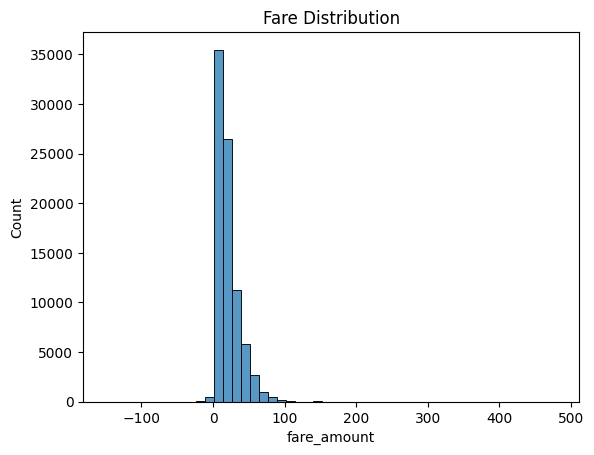

In [17]:
sns.histplot(df['fare_amount'], bins=50)
plt.title("Fare Distribution")
plt.show()

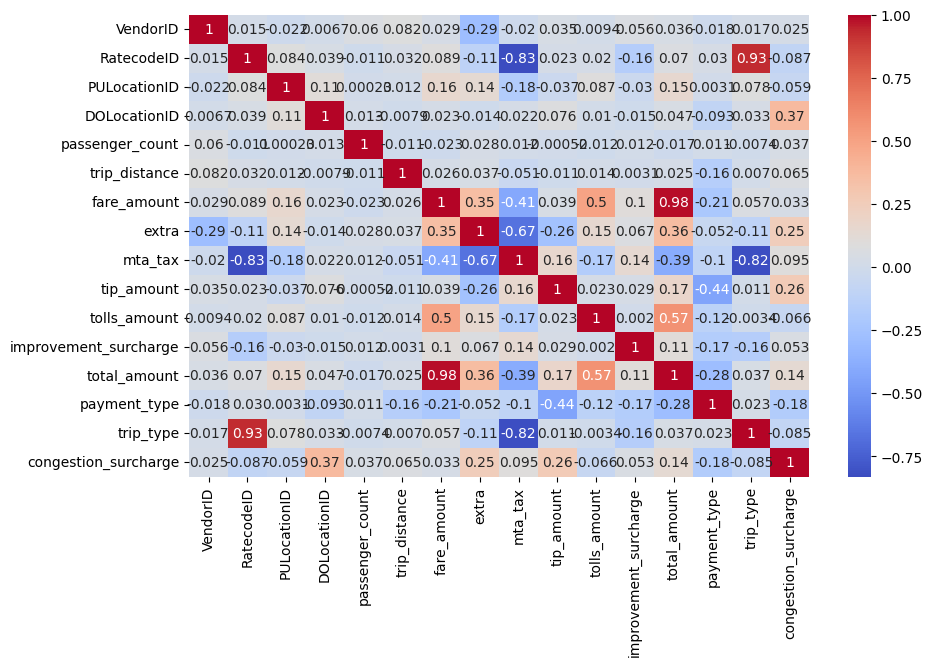

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

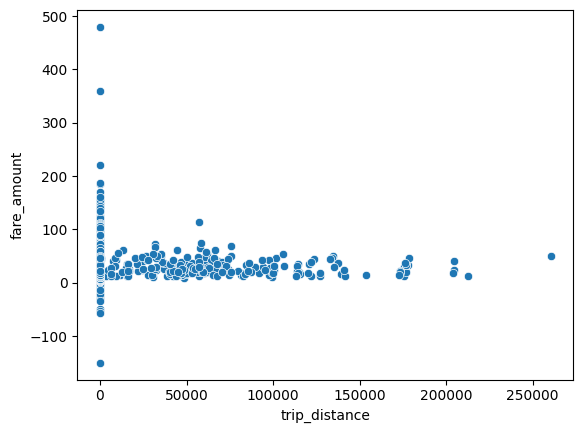

In [19]:
sns.scatterplot(x='trip_distance', y='fare_amount', data=df)
plt.show()

In [21]:
print(df['lpep_pickup_datetime'].dtype)

object


In [24]:
df['lpep_pickup_datetime'] = pd.to_datetime(df['lpep_pickup_datetime'])
df['lpep_dropoff_datetime'] = pd.to_datetime(df['lpep_dropoff_datetime'])
print(df['lpep_pickup_datetime'].dtype)
print(df['lpep_dropoff_datetime'].dtype)

datetime64[ns]
datetime64[ns]


In [25]:
df.columns.tolist()

['VendorID',
 'lpep_pickup_datetime',
 'lpep_dropoff_datetime',
 'store_and_fwd_flag',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'passenger_count',
 'trip_distance',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'payment_type',
 'trip_type',
 'congestion_surcharge']

In [26]:
# Extract time features
df['pickup_hour'] = df['lpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['lpep_pickup_datetime'].dt.dayofweek

# Optional: more useful features
df['pickup_month'] = df['lpep_pickup_datetime'].dt.month
df['pickup_dayofmonth'] = df['lpep_pickup_datetime'].dt.day

# Drop datetime columns
df = df.drop(['lpep_pickup_datetime', 'lpep_dropoff_datetime'], axis=1)

In [27]:
df.head()

,VendorID,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,...,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,pickup_hour,pickup_day,pickup_month,pickup_dayofmonth
0,1.0,N,1.0,74,168,1.0,1.20,6.0,0.5,0.5,...,0.0,0.3,7.30,2.0,1.0,0.0,0,3,7,1
1,2.0,N,1.0,116,265,2.0,13.69,42.0,0.5,0.5,...,0.0,0.3,43.30,2.0,1.0,0.0,0,3,7,1
2,2.0,N,1.0,97,33,1.0,0.95,6.5,0.5,0.5,...,0.0,0.3,10.14,1.0,1.0,0.0,0,3,7,1
3,2.0,N,1.0,74,42,1.0,1.24,6.5,0.5,0.5,...,0.0,0.3,7.80,2.0,1.0,0.0,0,3,7,1
4,2.0,N,1.0,42,244,1.0,1.10,7.0,0.5,0.5,...,0.0,0.3,8.30,2.0,1.0,0.0,0,3,7,1


In [28]:
df.columns.tolist()

['VendorID',
 'store_and_fwd_flag',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'passenger_count',
 'trip_distance',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'payment_type',
 'trip_type',
 'congestion_surcharge',
 'pickup_hour',
 'pickup_day',
 'pickup_month',
 'pickup_dayofmonth']

In [32]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop('fare_amount', axis=1)
y = df['fare_amount']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(66952, 20) (16739, 20)


In [33]:
print(X.dtypes)

VendorID                 float64
store_and_fwd_flag        object
RatecodeID               float64
PULocationID               int64
DOLocationID               int64
passenger_count          float64
trip_distance            float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
payment_type             float64
trip_type                float64
congestion_surcharge     float64
pickup_hour                int32
pickup_day                 int32
pickup_month               int32
pickup_dayofmonth          int32
dtype: object


In [34]:
X.select_dtypes(include='object').columns

Index(['store_and_fwd_flag'], dtype='object')

In [36]:
#checking values for object type columns
df['store_and_fwd_flag'].value_counts(dropna=False)

store_and_fwd_flag
N      50977
NaN    32518
Y        196
Name: count, dtype: int64

In [41]:
df['store_and_fwd_flag'] = (
    df['store_and_fwd_flag']
    .fillna('N')
    .map({'N': 0, 'Y': 1})
)

In [42]:
X = df.drop('fare_amount', axis=1)
y = df['fare_amount']

In [43]:
X.select_dtypes(include='object').columns

Index([], dtype='object')

In [44]:
X.isnull().sum().sum()

278799

In [46]:
df.isnull().sum()[df.isnull().sum() > 0]

VendorID                32518
store_and_fwd_flag      83691
RatecodeID              32518
passenger_count         32518
payment_type            32518
trip_type               32518
congestion_surcharge    32518
dtype: int64

In [47]:
df['VendorID'] = df['VendorID'].fillna(df['VendorID'].mode()[0])
df['RatecodeID'] = df['RatecodeID'].fillna(df['RatecodeID'].mode()[0])
df['passenger_count'] = df['passenger_count'].fillna(df['passenger_count'].median())
df['payment_type'] = df['payment_type'].fillna(df['payment_type'].mode()[0])
df['trip_type'] = df['trip_type'].fillna(df['trip_type'].mode()[0])
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(df['congestion_surcharge'].median())

In [48]:
X = df.drop('fare_amount', axis=1)

X.isnull().sum().sum()

83691

In [49]:
df.isnull().sum().sort_values(ascending=False)

store_and_fwd_flag       83691
VendorID                     0
tolls_amount                 0
pickup_month                 0
pickup_day                   0
pickup_hour                  0
congestion_surcharge         0
trip_type                    0
payment_type                 0
total_amount                 0
improvement_surcharge        0
tip_amount                   0
mta_tax                      0
extra                        0
fare_amount                  0
trip_distance                0
passenger_count              0
DOLocationID                 0
PULocationID                 0
RatecodeID                   0
pickup_dayofmonth            0
dtype: int64

In [50]:
df.drop(columns=['store_and_fwd_flag'], inplace=True)

In [51]:
df.isnull().sum().sum()

0

In [52]:
#recreating x and y after dropping store_and_fwd_flag
X = df.drop('fare_amount', axis=1)
y = df['fare_amount']

In [53]:
#train test split after handling missing values
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [54]:
X.isnull().sum().sum()

0

In [55]:
print(X.shape)
print(y.shape)

(83691, 19)
(83691,)


In [56]:
from sklearn.model_selection import train_test_split

# Remove fully-null column (if not already removed)
df = df.drop(columns=['store_and_fwd_flag'], errors='ignore')

# Features and target
X = df.drop(columns=['fare_amount'])
y = df['fare_amount']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (66952, 19)
X_test shape: (16739, 19)


In [57]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [58]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [59]:
rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    max_samples=0.5,   # uses only 50% data per tree
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [60]:
def evaluate(y_true, y_pred):
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2 Score:", r2_score(y_true, y_pred))

In [61]:
print("Linear Regression")
evaluate(y_test, y_pred_lr)

print("\nRandom Forest")
evaluate(y_test, y_pred_rf)

Linear Regression
MAE: 0.2204093596214169
RMSE: 0.4147655880056462
R2 Score: 0.9992780537054822

Random Forest
MAE: 0.3895820638046226
RMSE: 1.0365743301029648
R2 Score: 0.9954907910830577


In [64]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

In [65]:
grid = GridSearchCV(
    RandomForestRegressor(),
    {
        'n_estimators': [50],
        'max_depth': [10]
    },
    cv=2,
    n_jobs=-1
)

grid.fit(X_train, y_train)

,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [10], 'n_estimators': [50]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [67]:
print(len(df))

83691


In [68]:
df_sample = df.sample(frac=0.8, random_state=42)  # 80%

In [69]:
print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 50}


In [70]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
evaluate(y_test, y_pred)

MAE: 0.4036345094769903
RMSE: 0.963696126782606
R2 Score: 0.9961025577861805


In [72]:
import joblib

joblib.dump(best_model, "models/taxi_fare_model.pkl")

['models/taxi_fare_model.pkl']